# Customer Order Pattern Analysis

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
orders = pd.read_csv("orders.csv")
items = pd.read_csv("items.csv")
customers = pd.read_csv("customers.csv")

In [9]:
final_df = orders_items = orders.merge(items, on = "item_id" , how = "left")

In [10]:
final_df["total_amount"] = final_df["quantity"] * final_df["price_per_unit"]

In [11]:
final_df.head()

,order_id,customer_id,item_id,order_date,quantity,item_name,price_per_unit,total_amount
0,1,101,1,2024-01-01,2,Tomatoes,20,40
1,2,102,2,2024-01-04,4,Onions,25,100
2,3,103,3,2024-01-07,8,Milk,50,400
3,4,101,4,2024-01-10,7,Rice,60,420
4,5,102,5,2024-01-13,9,Chicken,200,1800


In [14]:
total_revenue = final_df["total_amount"].sum()
print("Total Revenue:", total_revenue)

Total Revenue: 8675


In [19]:
top_customers = final_df.groupby("customer_id")["total_amount"].sum().sort_values(ascending=False)
print("Top Customers:\n" , top_customers)

Top Customers:
 customer_id
102    2575
101    1990
104    1860
103    1830
105     420
Name: total_amount, dtype: int64


In [21]:
order_counts = final_df.groupby("customer_id")["order_id"].count()
order_counts

customer_id
101    5
102    5
103    4
104    3
105    3
Name: order_id, dtype: int64

In [25]:
# Fix date column
final_df["order_date"] = pd.to_datetime(final_df["order_date"])

# Extract month & week
final_df["month"] = final_df["order_date"].dt.month
final_df["week"] = final_df["order_date"].dt.isocalendar().week

# Grouping
monthly_trend = final_df.groupby("month")["total_amount"].sum()
weekly_trend = final_df.groupby("week")["total_amount"].sum()


In [34]:
#rfm = Recency,Frequency,Monetary
# calculate the latest order date
current_date = final_df["order_date"].max()

# RFM calculation
rfm = final_df.groupby("customer_id").agg({
    "order_date": lambda x: (current_date - x.max()).days,
    "order_id": "count",
    "total_amount": "sum"
})

rfm.columns = ["recency", "frequency", "monetary"]

print(rfm)


             recency  frequency  monetary
customer_id                              
101               12          5      1990
102                3          5      2575
103                0          4      1830
104                6          3      1860
105                9          3       420


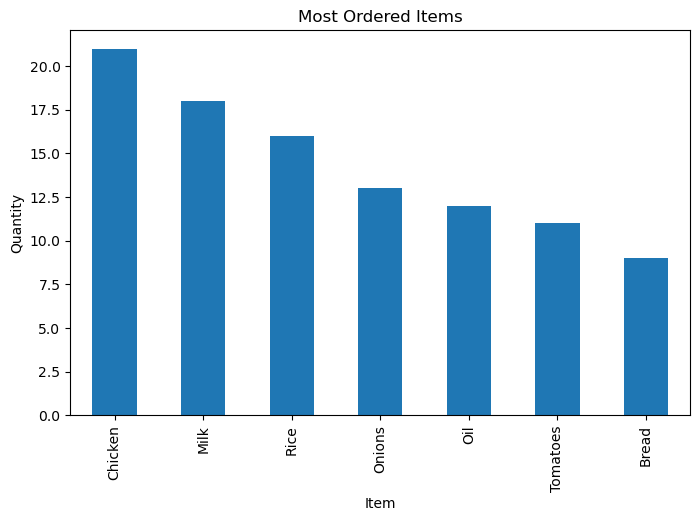

In [36]:
#most ordered items
top_items = final_df.groupby("item_name")["quantity"].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(8,5))
top_items.plot(kind = 'bar')
plt.title("Most Ordered Items")
plt.xlabel("Item")
plt.ylabel("Quantity")
plt.show()

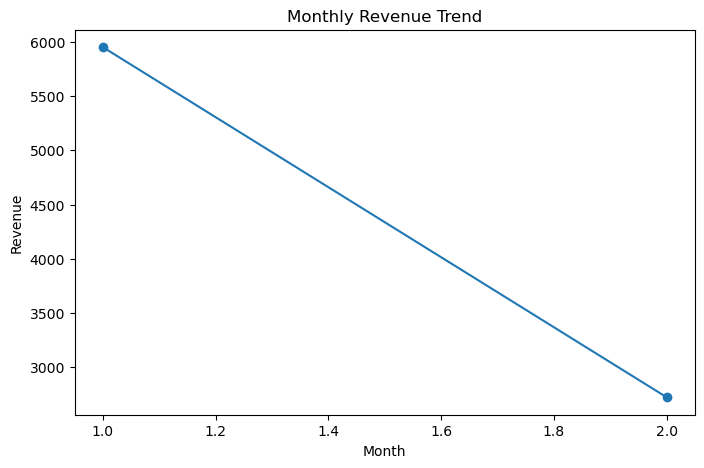

In [37]:
#monthly revenue trend
plt.figure(figsize=(8,5))
monthly_trend.plot(kind= 'line', marker = 'o')
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

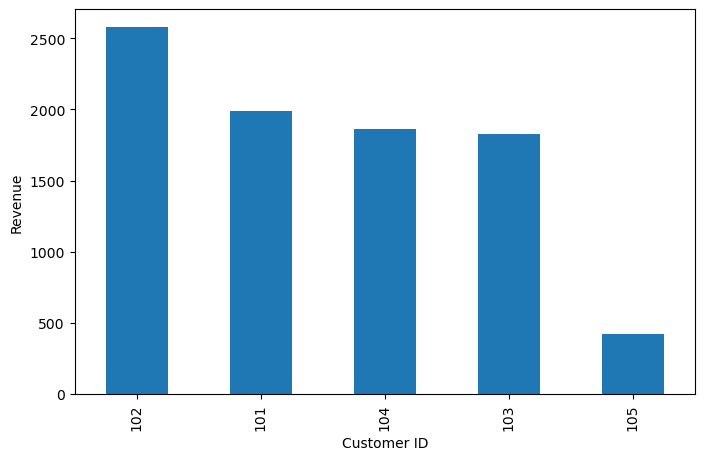

In [38]:
plt.figure(figsize=(8,5))
top_customers.plot(kind = 'bar')
plt.xlabel("Customer ID")
plt.ylabel("Revenue")
plt.show()

Summary:
This project analyzes customer ordering patterns using combined orders, items, and customer datasets. It explores purchase frequency, popular products, revenue trends, and customer behaviour through visualizations and metrics like RFM. The insights help businesses understand demand patterns, optimize inventory, segment customers, and improve data-driven decision-making for operational efficiency.